# 2.1.1 Functions

This is a small introduction to functions from the point of view of functional programming _and_ software engineering. It ends with a discussion about the basic way in which functions are represented in an object-oriented programming language like Scala. 

### References

_[Optional]_ __[Why Functional Programming Matters](https://www.cs.kent.ac.uk/people/staff/dat/miranda/whyfp90.pdf)__ John Hughes. This is a classic paper that motivates the need for functional programming by appealing to software enginerring principles such as modularity. It's written using the Miranda programming language, and it's more an academic paper that undergraduate material. Nevertheless, its reading is highly recommeded. Give it a try if you find some time!

__[Scala book (online)](https://docs.scala-lang.org/overviews/scala-book/introduction.html)__.

- [Pure functions](https://docs.scala-lang.org/overviews/scala-book/pure-functions.html)

## What are (pure) functions?

Functions are computational devices that transform input _values_ into output _values_, and do nothing _else_.

In [1]:
// `add one` function

def addOne(i: Int): Int = 
    i+1

defined function addOne

If we run this function, the only thing that happens is the computation of a new value:

In [2]:
addOne(5)

res1: Int = 6

Functions that do something else, besides returning values, are called _impure_ functions. Functional programming deals only with _pure_, or mathematical, functions.

In [3]:
// An impure function

def impureAdd(input: Int): Int = 
{
    println("¡sumando 1!")
    input + 1
}


defined function impureAdd

If we run this function, we will see an _effect_ in the console (besides the pure computation of `input + 1`): 

In [ ]:
impureAdd(5)

¡sumando 1!


res3: Int = 6

There are many kinds of effects: writing to the console, reading from the keyworkd, reading from a socket, calling a web service, executing a query over the database, etc. Clearly, we need effects if we want our programs to do something useful, so pure functions alone are not enough. We will talk about this later on.



## Functions as modularity devices

Why are functions so important in programming? Because they help us to _modularize_ our code. For instance, let's consider the following programs, which access the following data structure of key-value pairs (we will talk about this structure in detail later on):

In [2]:
val config: Map[String, String] = 
    Map("URL" -> "http://hablapps.com",
        "PORT" -> "8080")

config: Map[String, String] = Map(
  "URL" -> "http://hablapps.com",
  "PORT" -> "8080"
)

Our first program access the configuration data for the value of the "URL" key. If it's not found, then the default value "default.url" is returned (similarly, we will discuss the `match` keyword further in the course).

In [2]:
// Program 1
val url: String = config.get("URL") match {
  case Some(u) => u
  case None => "default.url"
}

url: String = "http://hablapps.com"

Our second program accesses the configuration data for the value of the "PORT" key. If it's not found, then the default value "8080" is returned.

In [3]:
// Program 2
val port: String = config.get("PORT") match {
  case Some(p) => p
  case None => "8080"
}

port: String = "8080"

These two programs do _almost_ the same. The only differences lie in the particular keys and default values the programs refer to, but, otherwise, they do the same thing. However, this _common factor_ is not reflected in the code. Indeed, we may get one program from the other by copy-pasting, a clear signal of [code-smell](https://en.wikipedia.org/wiki/Code_smell).

These programs are _monolythic_, in the sense that they are not made by composing large enough modules. In this case, the common logic of the program and the values it operates on are intermingled in the same code. 

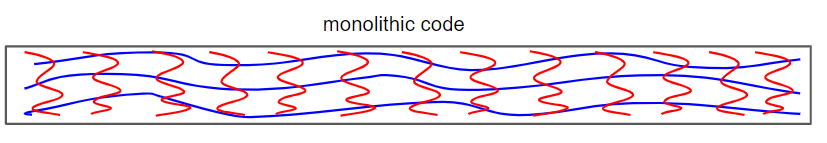

How can we abstract away the differences and package the common logic in a single module? With functions:

In [3]:
def getParameter(config: Map[String, String])(key: String, default: String): String = 
    config.get(key) match {
      case Some(p) => p
      case None => default
    }


defined function getParameter

This is an abstract module which we can combine with other modules to get back the very same functionality:

In [5]:
// Program 1
val url: String = getParameter(config)("URL", "default.url")

url: String = "http://hablapps.com"

In this case, we combine the module `getKeyFrom` with the modules (data values and variables, in particular) `config`, `"URL"` and `"default.url"`. The composition method is just simple function application.

Which are the advantages of using functions? As in the general case, having a more modular solution enables _reuse_, particularly of those modules which are abstract or parameterised. For instance, we can benefit from this level of reuse by re-implementing the `url` program in the following way:

In [4]:
// Program 2
val port: String = getParameter(config)("PORT", "8080")

port: String = "8080"

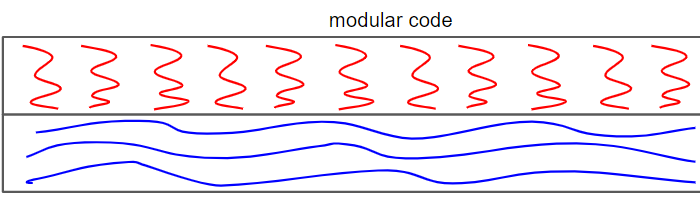

## Functions as methods

In an object-oriented language, functions are implemented through _methods_, i.e. using the `def` keyword. Note that these methods are invariably part of an `object`, `class` or `trait` declaration. Typically, pure functions are declared as part of objects. For instance, we may declare a set of arithmetic functions as follows: 

In [6]:
import scala.math.{pow, Pi}

object Areas{
    
    def circle(radius: Double): Double = 
        Pi*pow(radius, 2)
    
    def rectangle(width: Double, height: Double): Double = 
        width*height
}

import scala.math.{pow, Pi}


defined object Areas

In [10]:
Areas.circle(1)
Areas.circle

cmd10.sc:2: missing argument list for method circle in object Areas
Unapplied methods are only converted to functions when a function type is expected.
You can make this conversion explicit by writing `circle _` or `circle(_)` instead of `circle`.
val res10_1 = Areas.circle
                    ^Compilation Failed

: 

In notebooks and the Scala REPL, `def` declarations appear to be independent from any object or class, but they are not:

In [9]:
def foo(i: Int): Int = i
// show errors: "missing argument list for method foo in class Helper"


defined function foo

In [10]:
foo

cmd10.sc:1: missing argument list for method foo in class Helper
Unapplied methods are only converted to functions when a function type is expected.
You can make this conversion explicit by writing `foo _` or `foo(_)` instead of `foo`.
val res10 = foo
            ^Compilation Failed

: 

When we study higher-order functions, we will see that functions in Scala can also be represented as _objects_, i.e. not only as methods. However, that representation also builds essentially upon methods.

## Functions as values

Functions can also be represented as _values_, i.e. as objects. This allows us to implement functions that receive other functions as arguments, or return functions as results. This special functions are called _higher-order functions_ (HOF), and they feature as a great modularity device. We will mainly discuss this feature of HOFs in PF-3.

In order to represent functions as values, we need first to make extremely clear the difference between variables, values and types. For instance:


In [12]:
var b: Boolean = true

b: Boolean = false

In [13]:
b

res12: Boolean = true

In [14]:
b=false

In [15]:
b

res14: Boolean = false

In [16]:
// three variables
val i: Int = 1
val s: String = "hola"
val b: Boolean = true

i: Int = 1
s: String = "hola"
b: Boolean = true

In [16]:
b = false

cmd16.sc:1: reassignment to val
val res16 = b = false
              ^Compilation Failed

: 

In [ ]:
val f: <<function type>> = def foo(i: Int): Int = i

In these definitions, we found three variables: `i`, `s` and `b`. These variables are assigned three __values__: `3`, `"hi"` and `true`. The __types__ of these values are, respectively: `Int`, `String` and `Boolean`. Now, let's consider these other variables that we intend to represent values equivalent to the following function-methods:

In [28]:
// Function-methods

def addOneM(number: Int): Int = 
    number + 1

def substractOneM(number: Int): Int = 
    number - 1 

// Function-values

val addOneV: Int => Int = 
    (number: Int) => number+1 : Int

val substractOneV: Int => Int = 
    (number: Int) => number - 1 : Int  
    


defined function addOneM
defined function substractOneM
addOneV: Int => Int = ammonite.$sess.cmd27$Helper$$Lambda$2158/1922807165@7b059ec3
substractOneV: Int => Int = ammonite.$sess.cmd27$Helper$$Lambda$2159/161456561@207c5d88

In [22]:
def toStringM(i: Int): String = 
    i.toString

defined function toString

In [24]:
val toString2: Int => String = 
    (i: Int) => i.toString: String

toString2: Int => String = ammonite.$sess.cmd23$Helper$$Lambda$2152/103871545@366eb1dc

In [27]:
val toString2 = 
    (i: Int) => i.toString: String

toString2: Int => String = ammonite.$sess.cmd26$Helper$$Lambda$2156/937789623@63c3d4ed

In [25]:
val i: Int = 1

i: Int = 1

In [26]:
val i = 1

i: Int = 1

Here, we also have variables, values and types. The two variables are named `addOneV` and `substractOneV`. They are assigned the _function values_ `(a: Int) => a+1` and `(a: Int) => a - 1`. The type of these values is the same _function type_ `Int => Int`. A function-value is also known as a _lambda expression_. Note that a function value is made of two parts: the input arguments and the function body: `(...input...) => body`. The input arguments declare new variables, each of them of a particular type, that will be assigned to certain values when they are passed to the function (upon invocation). The function body has to be an expression of the type specified as output by the function type.

Function-values are equivalent to function-methods in the sense that they behave exactly in the same way, i.e. they allow us to compute values from other values that we pass as input:

In [31]:
// function-method invocations
addOneV(5)
addOneM(5)
// equivalent invocations with function-values
substractOneM(5)
substractOneV(5)

res30_0: Int = 6
res30_1: Int = 6
res30_2: Int = 4
res30_3: Int = 4

But then, which are the advantages of function values? Basically, they allow us to implement HOFs. For instance, let's say that we want to implement a HOF that receives an integer-to-integer function, such as `addOneM`and `substractOneM`, and calls this function over a given number. We may want to write something like this:

In [31]:
def call(def int2int(n: Int): Int, number: Int): Int =
    int2int(number)

(console):1:10 expected ")"
def call(def int2int(n: Int): Int, number: Int): Int =
         ^

: 

where the first argument `int2int` attempts to represent any function that receives an integer and returns another integer. 

But this code is not legal in Scala, because arguments to functions need to be values, not methods. That's why we need function-values!

In [33]:
def call(int2int: Int => Int, number: Int): Int =
    int2int(number)

defined function call

which we can use as follows:

In [34]:
val addOneV: Int => Int = (i: Int) => i+1

addOneV: Int => Int = ammonite.$sess.cmd33$Helper$$Lambda$2272/240743122@6472e4ae

In [35]:
// invoke call
call(addOneV, 7)

res34: Int = 8

In [36]:
call(substractOneV, 6)

res35: Int = 5

In [36]:
call(addOneV, "hola")

cmd36.sc:1: type mismatch;
 found   : String("hola")
 required: Int
val res36 = call(addOneV, "hola")
                          ^Compilation Failed

: 

In [37]:
val toString2: Int => String = (i: Int) => i.toString

toString2: Int => String = ammonite.$sess.cmd36$Helper$$Lambda$2298/770848303@49b5b278

In [37]:
call(toString2, 1)

cmd37.sc:1: type mismatch;
 found   : Int => String
 required: Int => Int
val res37 = call(toString2, 1)
                 ^Compilation Failed

: 

In [37]:
call(1, 1)

cmd37.sc:1: type mismatch;
 found   : Int(1)
 required: Int => Int
val res37 = call(1, 1)
                 ^Compilation Failed

: 

And we can even pass function-methods that are converted on the fly to function-values!

In [40]:
val addOneV: Int => Int = (i: Int) => i+1

addOneV: Int => Int = ammonite.$sess.cmd39$Helper$$Lambda$2304/475934189@fbc2753

In [38]:
// invoke call with function-methods
call(addOneV, 6)

res37: Int = 7

In [39]:
def addOneM(i: Int): Int = i+1

defined function addOneM

In [41]:
call(addOneM, 7)

res40: Int = 8

This conversion is the so-called _eta-expansion_.

In [42]:
val i: Int = 7

i: Int = 7

In [43]:
call(addOneV, i)

res42: Int = 8

In [44]:
call(addOneV, 7)

res43: Int = 8

In [45]:
call((x : Int) => x+1 : Int, 7 : Int)

res44: Int = 8

In [46]:
call((x : Int) => x+1, 7)

res45: Int = 8

In [47]:
call((x : Int) => x+1 : Int, 8 : Int)

res46: Int = 9

## Syntactic sugar for function-values

We discuss now some syntactic facilities offered by Scala when writing lambda expressions. 

First, we can omit the types of input arguments and let Scala figure out them:

In [49]:
val addOneV: Int => Int = 
    a => a + 1

val substractOneV: Int => Int = 
    a => a - 1

addOneV: Int => Int = ammonite.$sess.cmd48$Helper$$Lambda$2322/1602512793@4e326189
substractOneV: Int => Int = ammonite.$sess.cmd48$Helper$$Lambda$2323/849368141@2445746

In [51]:
def call(f: Int => Int, i: Int): Int = f(i)

defined function call

In [50]:
call(i => i+2, 7)

res49: Int = 9

In [52]:
val i = 1

i: Int = 1

In [53]:
val f = (i: Int) => i+1

f: Int => Int = ammonite.$sess.cmd52$Helper$$Lambda$2329/260874284@45b9b2c0

In [53]:
val f = i => i+1

cmd53.sc:1: missing parameter type
val f = i => i+1
        ^Compilation Failed

: 

In [54]:
val f: Int => Int = i => i+1

f: Int => Int = ammonite.$sess.cmd53$Helper$$Lambda$2334/173249627@bfa12c3

In [55]:
val f: Short => Int = i => i+1

f: Short => Int = ammonite.$sess.cmd54$Helper$$Lambda$2336/1658429625@3cebc7bc

In [56]:
val f: Float => Float = i => i+1

f: Float => Float = ammonite.$sess.cmd55$Helper$$Lambda$2339/657144130@1da15ac4

Second, we can get extra level of conciseness using so-called _underscore_ syntax:

In [60]:
val addOne: Int => Int = 
    _ + 1

addOne: Int => Int = ammonite.$sess.cmd59$Helper$$Lambda$2347/425234172@68b2e2a3

In [59]:
(a: Int)=>a+1

res58: Int => Int = ammonite.$sess.cmd58$Helper$$Lambda$2345/751171350@2bb8d9bf

In [61]:
call(_+1, 8)

res60: Int = 9

In [58]:
val addOne: Int => Int = 
    b => b + 1

addOne: Int => Int = ammonite.$sess.cmd57$Helper$$Lambda$2343/1277061780@f880843

In [8]:
// call((a: Int) => a + 1, 5)
// call((a: Int) => a - 1, 3)

## Currying

What about functions that receive more than one argument? We would like to implement the function-value equivalent of this function-method: 

In [62]:
// function-method sum
def sum(x: Int, y: Int): Int = 
    x+y

defined function sum

We do that as follows:

In [63]:
// function-value sum

val sum: (Int, Int) => Int = 
    (x: Int, y: Int) => x+y : Int

sum: (Int, Int) => Int = ammonite.$sess.cmd62$Helper$$Lambda$2355/1518449736@126a7e00

or, exploiting type inference:

In [64]:
// function-value sum, with type-inference & underscore syntax

val sum = (x: Int, y: Int) => x+y

sum: (Int, Int) => Int = ammonite.$sess.cmd63$Helper$$Lambda$2357/685985284@1222ec68

In [65]:
// function-value sum, with type-inference & underscore syntax

val sum: (Int, Int) => Int = (x, y) => x+y

sum: (Int, Int) => Int = ammonite.$sess.cmd64$Helper$$Lambda$2359/371594313@1815cd91

In [65]:
// function-value sum, with type-inference & underscore syntax

val sum = (x, y) => x+y

cmd65.sc:1: missing parameter type
val sum = (x, y) => x+y
           ^cmd65.sc:1: missing parameter type
val sum = (x, y) => x+y
              ^Compilation Failed

: 

In [66]:
val sum: (Int, Int) => Int = _+_

sum: (Int, Int) => Int = ammonite.$sess.cmd65$Helper$$Lambda$2361/54998225@3960169d

In [67]:
"hola"+" y adios"

res66: String = "hola y adios"

In [68]:
val sum: (Int, Int) => Int = _+_

sum: (Int, Int) => Int = ammonite.$sess.cmd67$Helper$$Lambda$2370/581451406@52c488f9

In [72]:
val sum: Int => (Int => Int) = 
    (x: Int) => 
        (y: Int) => x+y : Int

sum: Int => Int => Int = ammonite.$sess.cmd71$Helper$$Lambda$2384/1289193@46fb1500

However, function types of two, three, ... arguments are not extrictly necessary, and sometimes we can get along with functions of one argument. But, how can we create a function of two arguments with functions of one argument alone? The trick is the following:

In [8]:
// function-value sum, currified
val sum: Int => (Int => Int) = 
    (x: Int) => 
        (y: Int) => x+y : Int

Note that brackets in `Int => (Int => Int)` are used for clarity, but are not needed. Basically, we created a function of one argument that returns another function of one argument. So, the expression: 

In [76]:
// partial application
val addOne: Int => Int = sum(1)
addOne(6)
sum(1)(6)

addOne: Int => Int = ammonite.$sess.cmd71$Helper$$Lambda$2389/213039179@3ec5922b
res75_1: Int = 7
res75_2: Int = 7

returns a function that can be applied again:

In [8]:
// total application


We can apply this strategy to functions of any number of arguments. This is called _currying_ and _currified functions_. The analog in function-methods is [multiple-parameter lists](https://docs.scala-lang.org/tour/multiple-parameter-lists.html):

In [80]:
// function-method, with multi-parameter list
def sum(x: Int, y: Int): Int = 
    x+y

defined function sum

In [80]:
sum(1)

cmd80.sc:1: not enough arguments for method sum: (x: Int, y: Int): Int.
Unspecified value parameter y.
val res80 = sum(1)
               ^Compilation Failed

: 

In [78]:
// function-method, with multi-parameter list
def sum(x: Int)(y: Int): Int = 
    x+y

defined function sum

In [79]:
val f: Int => Int = sum(1) 

f: Int => Int = ammonite.$sess.cmd78$Helper$$Lambda$2397/1724710068@47cd0565

In [81]:
val f: (Int, Boolean, String, Float) => Boolean = 
    (x: Int, y: Boolean, z: String, v: Float) => 
        false : Boolean

f: (Int, Boolean, String, Float) => Boolean = ammonite.$sess.cmd80$Helper$$Lambda$2400/1233631124@213e239

In [83]:
val f: Int => (Boolean => (String => (Float => Boolean))) = 
    (x: Int) => ??? : (Boolean => (String => (Float => Boolean)))

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd82$Helper$$Lambda$2404/1262645352@1b49f4ff

In [84]:
val f: Int => (Boolean => (String => (Float => Boolean))) = 
    (x: Int) => (y: Boolean) => ??? : (String => (Float => Boolean))

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd83$Helper$$Lambda$2567/474314541@5e2cd240

In [85]:
val f: Int => (Boolean => (String => (Float => Boolean))) = 
    (x: Int) => (y: Boolean) => (z: String) => ??? : (Float => Boolean)

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd84$Helper$$Lambda$2569/2091323639@5a344f9

In [86]:
val f: Int => (Boolean => (String => (Float => Boolean))) = 
    (x: Int) => (y: Boolean) => (z: String) => (v: Float) => ??? : Boolean

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd85$Helper$$Lambda$2571/1578706865@13c523c4

In [87]:
val f: Int => (Boolean => (String => (Float => Boolean))) = 
    (x: Int) => (y: Boolean) => (z: String) => (v: Float) => false : Boolean

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd86$Helper$$Lambda$2573/222148247@145f8444

In [88]:
val f: Int => Boolean => String => Float => Boolean = 
    (x: Int) => (y: Boolean) => (z: String) => (v: Float) => false : Boolean

f: Int => Boolean => String => Float => Boolean = ammonite.$sess.cmd87$Helper$$Lambda$2575/1302954348@4dbecd5b

In [90]:
val f: (Int => String) => Boolean = 
    (g: Int => String) => ??? : Boolean

f: (Int => String) => Boolean = ammonite.$sess.cmd89$Helper$$Lambda$2582/211419891@2b9c2eeb

In [91]:
val g: Int => (String => Boolean) = 
    (i: Int) => ??? : (String => Boolean)

g: Int => String => Boolean = ammonite.$sess.cmd90$Helper$$Lambda$2584/1536954105@54f25970

## Functions compose

We can create new functions by composing other functions whose signatures match. This is great from a modularity perspective. For instance, the following function is implemented in a non-modular way:

In [1]:
"hola".length

res0: Int = 4

In [2]:
// isEvenLength
def isEvenLength(s: String): Boolean = 
    s.length % 2 == 0

defined function isEvenLength

In [4]:
isEvenLength("adios")

res3: Boolean = false

This function is somehow the combination of two more basic functions `length` and `isEven`:

In [7]:
// length 
"hola".length

def length(s: String): Int = 
    s.length

res6_0: Int = 4
defined function length

In [8]:
val f: String => Int = (s: String) => s.length

f: String => Int = ammonite.$sess.cmd7$Helper$$Lambda$1896/2075436288@6cc3eb1

In [9]:
val f: String => Int = _.length

f: String => Int = ammonite.$sess.cmd8$Helper$$Lambda$1904/666763149@4afe7dcc

In [5]:
// isEven
def isEven(n: Int): Boolean = 
    n % 2 == 0

defined function isEven

In [10]:
// isEvenLength
def isEvenLength(s: String): Boolean = 
    isEven(length(s))

defined function isEvenLength

In [11]:
isEvenLength("hola")

res10: Boolean = true

In [10]:
// isEvenLength
def isEvenLength(s: String): Boolean = 
    compose(isEven, length)(s)

defined function isEvenLength

In [10]:
// isEvenLength
val isEvenLength: String => Boolean = 
    compose(isEven, length)

defined function isEvenLength

In [13]:
val f: Int => Boolean = isEven

f: Int => Boolean = ammonite.$sess.cmd12$Helper$$Lambda$1921/1929499932@7f612fa8

In [14]:
isEven _

res13: Int => Boolean = ammonite.$sess.cmd13$Helper$$Lambda$1923/415399920@291995bb

but this is not reflected in the current implementation. How can we redefine the function `isEvenLength` using the functions `length` and `isEven`? We can use a HOF which helps us to compose functions:

In [15]:
// compose HOF
def compose(g: Int => Boolean, f: String => Int): String => Boolean = 
    ???

defined function compose

In [16]:
// compose HOF
def compose(g: Int => Boolean, f: String => Int): String => Boolean = 
    ??? : (String => Boolean)

defined function compose

In [18]:
// compose HOF
def compose(g: Int => Boolean, f: String => Int): String => Boolean = 
    (s: String) => ??? : Boolean

defined function compose

In [19]:
// compose HOF
def compose(g: Int => Boolean, f: String => Int): String => Boolean = 
    // s => isEven(length(s))
    (s: String) => g(f(s): Int) : Boolean

defined function compose

Then, we can redefine `isEvenLength` in a modular way from the `length` and `isEven` building blocks:

In [21]:
// ad-hoc
val isEvenLength: String => Boolean = (s: String) => isEven(length(s))

isEvenLength: String => Boolean = ammonite.$sess.cmd20$Helper$$Lambda$1941/2063391425@541715b0

In [22]:
// ad-hoc
val isEvenLength: String => Boolean = 
    compose(isEven, length)

isEvenLength: String => Boolean = ammonite.$sess.cmd18$Helper$$Lambda$1945/1732219434@4a49b90d

In [23]:
"hola"*6

res22: String = "holaholaholaholaholahola"

In [25]:
def isVowel(c: Char): Boolean = 
    c=='a' || c=='e' || c=='i' || c=='o' || c=='u'

defined function isVowel

In [26]:
"hola".count((c : Char) => isVowel(c))

res25: Int = 2

In [27]:
"hola".count(isVowel)

res26: Int = 2

In [28]:
val f1: String => Int = (s: String) => s.count(isVowel) : Int 
val f2: Int => Boolean = (i: Int) => i > 5 : Boolean 
val f3: String => Boolean = compose(f2, f1)

f1: String => Int = ammonite.$sess.cmd27$Helper$$Lambda$1964/1783585122@15ae092
f2: Int => Boolean = ammonite.$sess.cmd27$Helper$$Lambda$1965/1404083046@4672ff76
f3: String => Boolean = ammonite.$sess.cmd18$Helper$$Lambda$1945/1732219434@743f5204

In [32]:
val f1: String => Int = s => s.count(isVowel) 
val f2: Int => Boolean = i => i > 5 
val f3: String => Boolean = compose(f2, f1)

f1: String => Int = ammonite.$sess.cmd31$Helper$$Lambda$1975/1114108397@f025531
f2: Int => Boolean = ammonite.$sess.cmd31$Helper$$Lambda$1976/1509621870@736eb3f9
f3: String => Boolean = ammonite.$sess.cmd18$Helper$$Lambda$1945/1732219434@7869c38b

In [33]:
val f1: String => Int = _.count(isVowel) 
val f2: Int => Boolean = _ > 5 
val f3: String => Boolean = compose(f2, f1)

f1: String => Int = ammonite.$sess.cmd32$Helper$$Lambda$1980/143111110@13ead00
f2: Int => Boolean = ammonite.$sess.cmd32$Helper$$Lambda$1981/1372812327@7e2a0f8b
f3: String => Boolean = ammonite.$sess.cmd18$Helper$$Lambda$1945/1732219434@90ed17f

In [34]:

val f3: String => Boolean = compose(_ > 5, _.count(isVowel))

f3: String => Boolean = ammonite.$sess.cmd18$Helper$$Lambda$1945/1732219434@9edd4b2

In [40]:

val f3: String => Boolean = ((i: Int) => i > 5) compose (_.count(isVowel))

f3: String => Boolean = scala.Function1$$Lambda$1991/1785841194@30f4e425

In [31]:
f3("hola")
f3("abecedario")

res30_0: Boolean = false
res30_1: Boolean = true

The HOF `compose` is actually defined for function types of one argument: 

In [37]:
3 + 5 == 3.+(5)

res36: Boolean = true

In [38]:
// val isEvenLength: String => Boolean =
    (isEven _).compose(length)
    // isEven(length(s))

res37: String => Boolean = scala.Function1$$Lambda$1991/1785841194@79ac5b67

or using infix notation:

In [8]:
// val isEvenLength: String => Boolean = ???

Note that a similar function to `compose`, called `andThen`, is also available in the standard library: 

In [39]:
val isEvenLength: String => Boolean =
    //isEven compose length
    (length _) andThen isEven

isEvenLength: String => Boolean = scala.Function1$$Lambda$660/1794775792@133d27d9

The last implementation of the `compose` HOF was _monomorphic_, in the sense that it only works with specific types. We can obtain a more flexible implementation using generics, also known as _parametric polymorphism_:

In [47]:
val f1: Int => Char = (i: Int) => ??? : Char
val f2: Char => String = (c: Char) => ??? : String
val f3: Int => String = compose2(f2, f1)

f1: Int => Char = ammonite.$sess.cmd46$Helper$$Lambda$2065/855137140@492bd9f9
f2: Char => String = ammonite.$sess.cmd46$Helper$$Lambda$2066/1739290947@5a51f4e
f3: Int => String = ammonite.$sess.cmd42$Helper$$Lambda$2046/43135348@697c920e

In [41]:
def compose[A](f2: Int => Boolean, f1: A => Int): String => Boolean = 
    (a: String) => f2(f1(a))

defined function compose

In [43]:
def compose2(f2: Char => String, f1: Int => Char): Int => String = 
    a => f2(f1(a))


defined function compose2

In [45]:

def compose[A, B, C](f2: B => C, f1: A => B): A => C = 
    (a: A) => f2(f1(a))

defined function compose

In [45]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    ???

defined function compose

In [50]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    ??? : (A => C)

defined function foo

In [52]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    (a: A) => ??? : C

defined function foo

In [52]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    (a: A) => f2(??? : B) : C

defined function foo

In [53]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    (a: A) => f2(f1(??? : A) : B) : C

defined function foo

In [54]:

def foo[A, B, C](f2: B => C, f1: A => B): A => C = 
    (a: A) => f2(f1(a : A) : B) : C

defined function foo

In [56]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    ??? : (A => (C => B))

defined function foo

In [57]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    (a: A) => ??? : (C => B)

defined function foo

In [58]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    (a: A) => (c: C) => ??? : B

defined function foo

In [59]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    (a: A) => (c: C) => f1(??? : A) : B

defined function foo

In [60]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    (a: A) => (c: C) => f1(a : A) : B

defined function foo

In [61]:

def foo[A, B, C](f2: B => C, f1: A => B): A => (C => B) = 
    a => _ => f1(a)

defined function foo

In [62]:

def foo[A, B, C](f2: B => C, f1: A => B): C => A = 
    (c: C) => ??? : A

defined function foo

In [48]:
compose[String, Int, Boolean](isEven, length)
compose[Int, Char, String](f2, f1)

res47_0: String => Boolean = ammonite.$sess.cmd44$Helper$$Lambda$2063/960378412@48506e35
res47_1: Int => String = ammonite.$sess.cmd44$Helper$$Lambda$2063/960378412@5f076a72

In [49]:
compose(isEven, length)
compose(f2, f1)

res48_0: String => Boolean = ammonite.$sess.cmd44$Helper$$Lambda$2063/960378412@573555a
res48_1: Int => String = ammonite.$sess.cmd44$Helper$$Lambda$2063/960378412@94b6f84

We can also give a currified version of this function as follows:

In [63]:
// compose  as a function-method
def compose[A, B, C](f2: B => C, f1: A => B): A => C = 
    ??? 

defined function compose

In [67]:
// compose as a function-value
def compose[A, B, C]: (B => C, A => B) => (A => C) = 
    (f2: B => C, f1: A => B) => (a: A) => f2(f1(a)) : C

defined function compose

In [68]:
// compose as a currified function-value
def compose[A, B, C]: (B => C) => ((A => B) => (A => C)) = 
    (f2: B => C) => (f1: A => B) => (a: A) => f2(f1(a)) : C

defined function compose

In [69]:
// compose as a currified function-value (without redundant parenthesis)
def compose[A, B, C]: (B => C) => (A => B) => A => C = 
    (f2: B => C) => (f1: A => B) => (a: A) => f2(f1(a)) : C

defined function compose

In [68]:
// compose as a currified function-value
def compose[A, B, C]: (B => C) => ((A => B) => (A => C)) = 
    (f2: B => C) => (f1: A => B) => (a: A) => f2(f1(a)) : C

defined function compose

Last, there is a function which behaves as the identity element with respect to the operation `compose`, i.e. no matter which other function we choose to compose with the [`identity`](https://www.scala-lang.org/api/current/scala/Predef$.html) function, the result will be that function:
1. `identity[B] compose f == f` for all `f: A => B`
2. `f compose identity[A] == f` for all `f: A => B`

In [9]:
// function-method identity


or using lambda expressions:

In [9]:
// quasi function-value identity


## How are functions represented as values

Now, we just want to focus on how are functions actually represented as values in a OO language like Scala. This representation builds essentially upon methods, in particular, _reified_ methods. For instance, let's consider the following functions:

In [10]:
def addOneM(number: Int): Int = 
    number + 1

def substractOneM(number: Int): Int = 
    number - 1 

defined function addOneM
defined function substractOneM

In order to create a type of functions that receive an integer and return another one, we can create a new class whose only method is the function that we want to actually implement:

In [10]:
// FunctionInt2Int class 


Now, we can implement the `call` HOF as follows: 

In [10]:
// call HOF


In order to use this HOF with the `addOneM` and `substractOneM` functions, we must create reified versions for them: 

In [10]:
// addOneV and SubstractV function-values


We call the `addOneV` and `substractOneV` function-values, i.e. functions represented as values. Now, we can use the `call` HOF as follows:

In [10]:
// invoke call HOF

Actually, function types such as `Int => Int` and `Boolean => String` are syntactic sugar for the types `Function1[Int, Int]` and `Function1[Boolean, String]`, where [`Function1`](https://www.scala-lang.org/api/current/scala/Function1.html) is a generalization of the type `FunctionInt2Int` that we wrote above. We have also [`Function2`](https://www.scala-lang.org/api/current/scala/Function2.html), [`Function3`](https://www.scala-lang.org/api/current/scala/Function3.html), etc., that are roughly implemented as follows:

In [11]:
object Std{
    trait Function1[A, B]{
        def apply(a: A): B
    }

    trait Function2[A, B, C]{
        def apply(a: A, b: B): C
    }

    // up to Function22
}


defined object Std

Using these standard classes, we can create the `addOneV` function-value in a similar way than before: 

In [11]:
// addOneV as a Function1 instance


and invoke functions as follows:


In [11]:
// invoke addOneV


However, as we saw throughout this notebook, we can also invoke the function without explicitly naming the `apply` method, i.e. 

In [11]:
// omit apply!


This is just another syntactic nicety of Scala. In sum, in an object-oriented language like Scala, function-values are ultimately methods in disguise.